Assessment of Satellite-derived Building Datasets - Vector Dataset - World Bank - June 2026
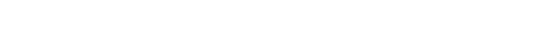

AVERAGE PERFORMANCE OF VECTOR DATASET

Which vector global building dataset is most accurate overall? How does each vector dataset win based on the accuracy distribution?


In [ ]:
# ── Presentation palette & style ──────────────────────────────────────────────
FONT_FAMILY = 'Barlow, Barlow Semi Condensed, Arial, sans-serif'

DATASET_COLORS = {
    'overture':            '#1B6CA8',
    'gba':                 '#2BAE82',
    'globfp':              '#66C7E0',
    'wsf_tracker_10m':     '#C94A35',
    'obt_2023_10m':        '#E0882A',
    'wsf_tracker_100m':    '#EFB3A9',
    'obt_2023_100m':       '#F5C98A',
    'ghsl_built_s_2025':   '#CC2266',
    'tempo_2023q4':        '#7B4EBD',
}

DATASET_LABELS = {
    'overture':            'Overture Maps',
    'gba':                 'Google Open Buildings',
    'globfp':              'GlobFP',
    'ghsl_built_s_2025':   'GHSL 2025 (100m)',
    'tempo_2023q4':        'TEMPO Q4 2023 (100m)',
    'obt_2023':            'OBT 2023',
    'wsf_tracker':         'WSF Tracker',
    'wsf_tracker_10m':     'WSF Tracker (10m)',
    'wsf_tracker_100m':    'WSF Tracker (100m)',
    'obt_2023_10m':        'OBT 2023 (10m)',
    'obt_2023_100m':       'OBT 2023 (100m)',
}

def _dataset_color(name):
    return DATASET_COLORS.get(str(name).lower().strip(), '#888888')

def apply_ppt_style(fig):
    fig.update_layout(
        font=dict(family=FONT_FAMILY, size=14, color='#1a1a1a'),
        title_font=dict(size=20, family=FONT_FAMILY),
        legend=dict(font=dict(size=13), bgcolor='rgba(255,255,255,0.9)',
                    bordercolor='#CCCCCC', borderwidth=1),
        plot_bgcolor='white', paper_bgcolor='white',
        margin=dict(t=80, b=60, l=70, r=30),
        width=1280, height=720,
    )
    fig.update_xaxes(title_font=dict(size=15), tickfont=dict(size=13),
                     gridcolor='#E8E8E8', linecolor='#CCCCCC')
    fig.update_yaxes(title_font=dict(size=15), tickfont=dict(size=13),
                     gridcolor='#E8E8E8', linecolor='#CCCCCC')
    return fig

In [13]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd
import numpy as np
import re, os
from IPython.display import display, HTML

FONT_COLOR  = '#222222'
BG_COLOR    = 'white'
FONT_SIZE   = 16
print('Setup done')

# ── Helper: show a figure, then insert a visible line space below it ──
GAP_PX = 48   # increase for a bigger gap between figures
def show_with_gap(fig, gap=GAP_PX):
    fig.show()
    display(HTML(f"<div style='height:{gap}px;line-height:{gap}px'>&nbsp;</div>"))

# Define OUT_DIR and create it if it doesn't exist
OUT_DIR = '/content/output_images/'
os.makedirs(OUT_DIR, exist_ok=True)

from google.colab import files as _colab_files
import io as _io
print('Please upload vector_all_cities_merged.csv')
_uploaded = _colab_files.upload()
_fname = next(iter(_uploaded))
df_raw = pd.read_csv(_io.BytesIO(_uploaded[_fname]))
df_raw = df_raw.loc[:, ~df_raw.columns.duplicated()].copy()

def norm(c):
    s = re.sub(r'\s+', '_', str(c).strip().lower())
    s = re.sub(r'[^a-z0-9_]', '_', s)
    return re.sub(r'_+', '_', s).strip('_')
df_raw.columns = [norm(c) for c in df_raw.columns]

num_cols = ['n_ref_total', 'n_cand_total', 'count_ratio_total',
            'rel_count_delta_total', 'tp_total', 'fp_total', 'fn_total',
            'precision_city', 'recall_city', 'f1_city',
            'iou_mean_tp', 'boundary_f_meanpair_tp',
            'rel_area_error_mean_tp', 'total_area_bias']
for c in num_cols:
    if c in df_raw.columns:
        df_raw[c] = pd.to_numeric(df_raw[c], errors='coerce')
df = df_raw.drop_duplicates(subset=['city', 'dataset'], keep='first').reset_index(drop=True)

# precision_city, recall_city, f1_city are read directly from CSV
for _c in ['precision_city', 'recall_city', 'f1_city']:
    if _c in df.columns:
        df[_c] = pd.to_numeric(df[_c], errors='coerce')

all_datasets = sorted(df['dataset'].dropna().unique().tolist())
print(f"Datasets detected: {all_datasets}")

colors = {ds: DATASET_COLORS.get(ds, '#888888') for ds in all_datasets}
dataset_labels = {ds: DATASET_LABELS.get(ds, ds) for ds in all_datasets}

base_layout = dict(
    font=dict(family=FONT_FAMILY, size=FONT_SIZE, color=FONT_COLOR),
    plot_bgcolor=BG_COLOR,
    paper_bgcolor=BG_COLOR,
    margin=dict(l=60, r=30, t=80, b=60),
    title_x=0.5,
    title_xanchor='center',
)

def merged_layout(**overrides):
    out = {k: v for k, v in base_layout.items()}
    out.update(overrides)
    return out

summary = df.groupby('dataset').agg(
    n_cities=('city', 'nunique'),
    total_ref_buildings=('n_ref_total', 'sum'),
    total_candidates=('n_cand_total', 'sum'),
    total_TP=('tp_total', 'sum'),
    total_FP=('fp_total', 'sum'),
    total_FN=('fn_total', 'sum'),
    mean_precision=('precision_city', 'mean'),
    mean_recall=('recall_city', 'mean'),
    mean_F1=('f1_city', 'mean'),
).reset_index()

summary['macro_precision'] = summary['total_TP'] / (summary['total_TP'] + summary['total_FP'])
summary['macro_recall']    = summary['total_TP'] / (summary['total_TP'] + summary['total_FN'])
summary['macro_F1'] = 2 * (summary['macro_precision'] * summary['macro_recall']) / \
                      (summary['macro_precision'] + summary['macro_recall'])
summary['pred_ratio'] = summary['total_candidates'] / summary['total_ref_buildings']

summary_by_id = summary.set_index('dataset').copy()

summary['dataset'] = summary['dataset'].map(dataset_labels)

for ds in all_datasets:
    s = df[df['dataset'] == ds]
    TP, FP, FN = s['tp_total'].sum(), s['fp_total'].sum(), s['fn_total'].sum()
    P = TP / (TP + FP) if (TP + FP) else np.nan
    R = TP / (TP + FN) if (TP + FN) else np.nan
    F = 2 * P * R / (P + R) if (P + R) else np.nan
    print(f"  {dataset_labels[ds]:<10} n={s['city'].nunique():>3}  "
          f"TP={int(TP):>9}  FP={int(FP):>9}  FN={int(FN):>9}  "
          f"P={P:.7f}  R={R:.7f}  F1={F:.7f}")
print()

coverage = df.groupby('dataset')['city'].nunique()
all_cities = sorted(df['city'].dropna().unique().tolist())
print("Dataset city coverage:")
for ds in all_datasets:
    print(f"  {dataset_labels[ds]}: {coverage.get(ds, 0)} / {len(all_cities)} regions")
print()

pivot_f1 = df.pivot(index='city', columns='dataset', values='f1_city')

missing_report = pivot_f1.isna().sum()
if missing_report.sum() > 0:
    print("NOTE: missing (region, dataset) combinations:")
    print(missing_report.to_string())
    missing_pairs = (pivot_f1.isna().stack().loc[lambda s: s].index.tolist())
    print(f"  Missing pairs: {missing_pairs}")
    print()

common_cities_mask = pivot_f1.notna().all(axis=1)
fair_pivot = pivot_f1.loc[common_cities_mask]
winners_fair = fair_pivot.idxmax(axis=1).map(dataset_labels)
winner_counts_fair = winners_fair.value_counts()

valid_rows = pivot_f1.dropna(how='all')
winners_all = valid_rows.idxmax(axis=1, skipna=True).map(dataset_labels)
winner_counts_all = winners_all.value_counts()

for ds in all_datasets:
    lbl = dataset_labels[ds]
    if lbl not in winner_counts_fair.index:
        winner_counts_fair[lbl] = 0
    if lbl not in winner_counts_all.index:
        winner_counts_all[lbl] = 0
winner_counts_fair = winner_counts_fair.sort_values(ascending=False)
winner_counts_all  = winner_counts_all.sort_values(ascending=False)

winner_counts = winner_counts_all

pred_bias = df.groupby('dataset').agg(
    mean_precision=('precision_city', 'mean'),
    mean_recall=('recall_city', 'mean'),
    total_FP=('fp_total', 'sum'),
    total_FN=('fn_total', 'sum'),
).reset_index()
pred_bias['FP_FN_ratio'] = np.where(pred_bias['total_FN'] > 0,
                                    pred_bias['total_FP'] / pred_bias['total_FN'],
                                    np.nan)
pred_bias['dataset'] = pred_bias['dataset'].map(dataset_labels)

print("  FP/FN ratio > 1 = over-prediction; < 1 = under-prediction")
print(pred_bias.to_string(index=False, float_format='%.7f'))
print()

city_max_f1 = df.groupby('city')['f1_city'].max().dropna().sort_values(ascending=True)
cities_sorted = city_max_f1.index.tolist()

mid = len(cities_sorted) // 2
cities_left = cities_sorted[:mid]
cities_right = cities_sorted[mid:]

fig1 = make_subplots(rows=1, cols=2, shared_xaxes=True)

for ds in all_datasets:
    ds_series = (df[df['dataset'] == ds]
                 .drop_duplicates('city')
                 .set_index('city')['f1_city'])

    f1_left = [ds_series.get(c, np.nan) for c in cities_left]
    fig1.add_trace(go.Bar(
        y=cities_left, x=f1_left,
        name=dataset_labels[ds], orientation='h',
        marker=dict(color=colors[ds], line=dict(width=0.5, color='white')),
        text=[f'{v:.4f}' if pd.notna(v) else '' for v in f1_left],
        textposition='outside',
        textfont=dict(size=12, family=FONT_FAMILY, color=FONT_COLOR),
        cliponaxis=False, legendgroup=ds, showlegend=True,
    ), row=1, col=1)

    f1_right = [ds_series.get(c, np.nan) for c in cities_right]
    fig1.add_trace(go.Bar(
        y=cities_right, x=f1_right,
        name=dataset_labels[ds], orientation='h',
        marker=dict(color=colors[ds], line=dict(width=0.5, color='white')),
        text=[f'{v:.4f}' if pd.notna(v) else '' for v in f1_right],
        textposition='outside',
        textfont=dict(size=12, family=FONT_FAMILY, color=FONT_COLOR),
        cliponaxis=False, legendgroup=ds, showlegend=False,
    ), row=1, col=2)

for col in [1, 2]:
    fig1.update_xaxes(
        title='F1 Score', range=[0, 1.0],
        gridcolor='#E0E0E0', gridwidth=0.5, showgrid=True,
        tickformat='.2f', tickfont=dict(size=14, family=FONT_FAMILY),
        row=1, col=col,
    )
    fig1.update_yaxes(
        title='', tickfont=dict(size=14, family=FONT_FAMILY),
        row=1, col=col,
    )

fig1.add_vline(x=0.5, line_dash='dash', line_color='gray', opacity=0.4, row=1, col=1)
fig1.add_vline(x=0.5, line_dash='dash', line_color='gray', opacity=0.4, row=1, col=2)

panel_height = max(400, max(len(cities_left), len(cities_right)) * 38)

fig1.update_layout(
    **base_layout,
    title=dict(text='F1 Score per Dataset per Region (AoI)', font=dict(size=20)),
    barmode='group', bargap=0.15, bargroupgap=0.05,
    legend=dict(x=0.50, y=-0.05, xanchor='center', orientation='h',
                bgcolor='rgba(255,255,255,0.9)',
                bordercolor='#CCCCCC', borderwidth=1,
                font=dict(size=14, family=FONT_FAMILY)),
    height=panel_height, width=1600,
)
fig1.update_annotations(font=dict(family=FONT_FAMILY, size=16, color=FONT_COLOR))

fig1.write_image(os.path.join(OUT_DIR, 'task1_f1_per_city.png'), scale=2)
apply_ppt_style(fig1)
show_with_gap(fig1)

# Macro F1: mean of per-city values ±SD
_f1_agg = df.groupby('dataset').agg(
    mean_prec=('precision_city', 'mean'), sd_prec=('precision_city', 'std'),
    mean_rec =('recall_city',    'mean'), sd_rec =('recall_city',    'std'),
    mean_f1  =('f1_city',        'mean'), sd_f1  =('f1_city',        'std'),
).reindex(all_datasets)
metrics = [
    ('mean_prec', 'sd_prec', 'Precision'),
    ('mean_rec',  'sd_rec',  'Recall'),
    ('mean_f1',   'sd_f1',   'F1 (Macro)'),
]

fig2 = make_subplots(
    rows=1, cols=3,
    subplot_titles=[title for *_, title in metrics],
    horizontal_spacing=0.08,
)

for idx, (val_col, sd_col, title) in enumerate(metrics):

    vals = _f1_agg[val_col]
    sds  = _f1_agg[sd_col].fillna(0)
    x_labels = [dataset_labels[d] for d in all_datasets]

    fig2.add_trace(go.Bar(
        x=x_labels, y=vals.values,
        error_y=dict(type='data', array=sds.values.tolist(), visible=True),
        marker=dict(color=[colors[d] for d in all_datasets],
                    line=dict(width=1, color='white')),
        text=[f'<b>{v:.4f}</b>' for v in vals.values],
        textposition='outside',
        textfont=dict(size=13, family=FONT_FAMILY, color=FONT_COLOR),
        cliponaxis=False, showlegend=False,
    ), row=1, col=idx + 1)

    fig2.update_xaxes(tickfont=dict(family=FONT_FAMILY, size=14),
                      showgrid=False, row=1, col=idx + 1)
    fig2.update_yaxes(tickfont=dict(family=FONT_FAMILY, size=14),
                      gridcolor='#E0E0E0', gridwidth=0.5, showgrid=True,
                      range=[0, 1.05], row=1, col=idx + 1)

fig2.update_layout(
    **base_layout,
    title=dict(text='Aggregated Performance Across All Regions',
               font=dict(size=20)),
    height=500, width=1100,
)
fig2.update_annotations(font=dict(family=FONT_FAMILY, size=16, color=FONT_COLOR))

fig2.write_image(os.path.join(OUT_DIR, 'task1_mean_metrics.png'), scale=2)
apply_ppt_style(fig2)
show_with_gap(fig2)

pie_series = winner_counts[winner_counts > 0].copy()
pie_labels = pie_series.index.tolist()
pie_values = pie_series.values.tolist()
total_cities = sum(pie_values)

reverse_labels = {v: k for k, v in dataset_labels.items()}
pie_colors = [colors[reverse_labels[lbl]] for lbl in pie_labels]

shares = [v / total_cities for v in pie_values] if total_cities else []
SMALL_THRESHOLD = 0.05
pull_vals       = [0.18 if s < SMALL_THRESHOLD else 0.04 for s in shares]
text_positions  = ['outside' if s < SMALL_THRESHOLD else 'inside' for s in shares]
text_colors     = [FONT_COLOR if s < SMALL_THRESHOLD else 'white' for s in shares]

if len(pie_values) > 0:
    max_idx = int(np.argmax(pie_values))
    pull_vals[max_idx] = max(pull_vals[max_idx], 0.10)

fig3 = go.Figure(data=[go.Pie(
    labels=pie_labels,
    values=pie_values,
    pull=pull_vals,
    marker=dict(colors=pie_colors, line=dict(color='white', width=2.5)),
    texttemplate='<b>%{label}</b><br>%{value} regions (%{percent})',
    textposition=text_positions,
    insidetextorientation='horizontal',
    insidetextfont=dict(size=15, family=FONT_FAMILY, color='white'),
    outsidetextfont=dict(size=15, family=FONT_FAMILY, color=FONT_COLOR),
    hovertemplate='%{label}: %{value} regions (%{percent})<extra></extra>',
    hole=0, sort=False, rotation=45,
    automargin=True,
)])

fig3.update_traces(textfont=dict(color=text_colors, family=FONT_FAMILY, size=15))

fig3.update_layout(
    **merged_layout(
        title=dict(text='Best F1 Score Distribution by Dataset', font=dict(size=20)),
        showlegend=True,
        legend=dict(orientation='h', yanchor='bottom', y=-0.18,
                    xanchor='center', x=0.5,
                    font=dict(size=14, family=FONT_FAMILY),
                    bgcolor='rgba(255,255,255,0.9)',
                    bordercolor='#CCCCCC', borderwidth=1),
        height=720, width=820,
        margin=dict(l=80, r=80, t=90, b=120),
        annotations=[dict(text=f'Total: {total_cities} regions',
                          x=0.5, y=-0.10, showarrow=False,
                          font=dict(size=18, family=FONT_FAMILY, color='gray'),
                          xref='paper', yref='paper')],
    )
)

fig3.write_image(os.path.join(OUT_DIR, 'task1_f1_pie_distribution.png'), scale=2)
apply_ppt_style(fig3)
show_with_gap(fig3)

bar_series = winner_counts.sort_values(ascending=True)
bar_labels = bar_series.index.tolist()
bar_values = bar_series.values.tolist()
bar_colors = [colors[reverse_labels[lbl]] for lbl in bar_labels]

fig3b = go.Figure(go.Bar(
    x=bar_values, y=bar_labels, orientation='h',
    marker=dict(color=bar_colors, line=dict(width=1, color='white')),
    text=[f'{v} cit{"y" if v == 1 else "ies"} '
          f'({v / total_cities * 100:.1f}%)' for v in bar_values],
    textposition='outside',
    textfont=dict(size=14, family=FONT_FAMILY, color=FONT_COLOR),
    cliponaxis=False,
    hovertemplate='%{y}: %{x} regions<extra></extra>',
))

fig3b.update_layout(
    **base_layout,
    title=dict(text='Best F1 Score Distribution by Dataset (count view)', font=dict(size=20)),
    xaxis=dict(title='Regions won', gridcolor='#E0E0E0',
               tickfont=dict(size=13, family=FONT_FAMILY),
               range=[0, max(bar_values) * 1.18 if bar_values else 1]),
    yaxis=dict(title='', tickfont=dict(size=14, family=FONT_FAMILY)),
    height=460, width=900,
    annotations=[dict(text=f'Total: {total_cities} regions',
                      x=1.0, y=1.08, showarrow=False, xanchor='right',
                      font=dict(size=14, family=FONT_FAMILY, color='gray'),
                      xref='paper', yref='paper')],
)

fig3b.write_image(os.path.join(OUT_DIR, 'f1_bar_distribution.png'), scale=2)
apply_ppt_style(fig3b)
show_with_gap(fig3b)

Setup done
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Datasets detected: ['gba', 'globfp', 'overture']
  GBA        n=125  TP=  1776285  FP=  1517829  FN=   985941  P=0.5392300  R=0.6430629  F1=0.5865869
  GlobFP     n=113  TP=  1029318  FP=  1429145  FN=  1565621  P=0.4186835  R=0.3966637  F1=0.4073763
  Overture   n=130  TP=  2295731  FP=  1007194  FN=   490684  P=0.6950600  R=0.8239013  F1=0.7540164

Dataset city coverage:
  GBA: 125 / 130 regions
  GlobFP: 113 / 130 regions
  Overture: 130 / 130 regions

NOTE: missing (region, dataset) combinations:
dataset
gba          5
globfp      17
overture     0
  Missing pairs: [('afg-poruns', 'globfp'), ('cvg-saint-vincent-grenadines', 'globfp'), ('grd-grenada', 'globfp'), ('jpn-ashiya-hama', 'gba'), ('jpn-ashiya-hama', 'globfp'), ('jpn-iwate', 'globfp'), ('jpn-izu-oshima', 'globfp'), ('jpn-numakunai', 'globfp'), ('kwt-kuwaitcity', 'globfp'), ('ner-mli-kan

SIGNED AREA BIAS OF VECTOR DATASET

Do the vector datasets systematically overestimate or underestimate building size? Where do over- and underestimation concentrate geographically? How consistent is each dataset accuracy across world regions?


BUILDING SIZE AND DENSITY - RASTER DATASET

Where do performance differences emerge—do raster datasets struggle with small buildings, in dense areas, or across regions—and in which situations does one dataset outperform another?

In [14]:
df['total_area_bias']    = pd.to_numeric(df['total_area_bias'], errors='coerce')
df['rel_area_error_mean_tp'] = pd.to_numeric(df['rel_area_error_mean_tp'], errors='coerce')

# ── Safety: define the spacer helper if this cell runs on its own ──
try:
    show_with_gap
except NameError:
    from IPython.display import display, HTML
    GAP_PX = 48
    def show_with_gap(fig, gap=GAP_PX):
        fig.show()
        display(HTML(f"<div style='height:{gap}px;line-height:{gap}px'>&nbsp;</div>"))

bias_summary = df.groupby('dataset').agg(
    n_cities=('city', 'nunique'),
    bias_mean=('total_area_bias', 'mean'),
    bias_std=('total_area_bias', 'std'),
    bias_median=('total_area_bias', 'median'),
    bias_min=('total_area_bias', 'min'),
    bias_max=('total_area_bias', 'max'),
    bias_p25=('total_area_bias', lambda x: x.quantile(0.25)),
    bias_p75=('total_area_bias', lambda x: x.quantile(0.75)),
).reset_index()
bias_summary['dataset'] = bias_summary['dataset'].map(dataset_labels)

print("  Positive = overestimates building size; Negative = underestimates")
print(bias_summary.to_string(index=False, float_format='%.7f'))
print()

bias_mean_by_ds = {ds: df[df['dataset'] == ds]['total_area_bias'].mean()
                   for ds in all_datasets}

large_bias = df[df['total_area_bias'].abs() > 0.10][
    ['city', 'dataset', 'total_area_bias', 'rel_area_error_mean_tp']
].copy()
large_bias['dataset'] = large_bias['dataset'].map(dataset_labels)
large_bias['bias_pct'] = (large_bias['total_area_bias'] * 100).round(2)
large_bias = large_bias.sort_values('total_area_bias', ascending=False)

print("  merging adjacent structures (+), clipping/shrinkage (-)")
if large_bias.empty:
    print("  (no regions exceed the |bias| > 10% threshold)")
else:
    print(large_bias.to_string(index=False, float_format='%.7f'))
print()

city_order_bias = (df.groupby('city')['total_area_bias']
                     .apply(lambda x: x.abs().max())
                     .dropna().sort_values(ascending=True).index.tolist())
midb = len(city_order_bias) // 2
cities_bias_left, cities_bias_right = city_order_bias[:midb], city_order_bias[midb:]

fig12 = make_subplots(rows=1, cols=2, shared_xaxes=True)
for ds in all_datasets:
    s = df[df['dataset'] == ds].drop_duplicates('city').set_index('city')['total_area_bias']
    for col, grp in [(1, cities_bias_left), (2, cities_bias_right)]:
        vals = [s.get(c, np.nan) for c in grp]
        fig12.add_trace(go.Scatter(
            y=grp, x=vals, mode='markers+text', name=dataset_labels[ds],
            marker=dict(color=colors[ds], size=9, symbol='circle',
                        line=dict(width=1, color='white')),
            text=[f'{v:.4f}' if pd.notna(v) else '' for v in vals],
            textposition='middle right',
            textfont=dict(size=8, family=FONT_FAMILY, color=colors[ds]),
            hovertemplate='<b>%{y}</b><br>Bias: %{x:.7f}<extra></extra>',
            cliponaxis=False, legendgroup=ds, showlegend=(col == 1),
        ), row=1, col=col)

for col in [1, 2]:
    fig12.update_xaxes(title='Total Area Bias', gridcolor='#E0E0E0', zeroline=True,
                       zerolinecolor='black', zerolinewidth=1, tickformat='.2f',
                       tickfont=dict(size=13, family=FONT_FAMILY), row=1, col=col)
    fig12.update_yaxes(title='', tickfont=dict(size=11, family=FONT_FAMILY), row=1, col=col)
    fig12.add_vline(x=0,     line_width=2, line_color='black', opacity=0.5, row=1, col=col)
    fig12.add_vline(x=0.10,  line_dash='dot', line_color='red', opacity=0.4, row=1, col=col)
    fig12.add_vline(x=-0.10, line_dash='dot', line_color='red', opacity=0.4, row=1, col=col)

panel_h_bias = max(650, max(len(cities_bias_left), len(cities_bias_right)) * 26)
fig12.update_layout(
    **base_layout,
    title=dict(text='Total Area Bias per Dataset per Region', font=dict(size=20)),
    legend=dict(x=0.5, y=-0.05, xanchor='center', orientation='h',
                bgcolor='rgba(255,255,255,0.9)', bordercolor='#CCCCCC', borderwidth=1,
                font=dict(size=12, family=FONT_FAMILY)),
    height=panel_h_bias, width=1300,
)
fig12.update_annotations(font=dict(family=FONT_FAMILY, size=16, color=FONT_COLOR))
fig12.write_image(os.path.join(OUT_DIR, 'task4_signed_bias_dotplot.png'), scale=2)
apply_ppt_style(fig12)
show_with_gap(fig12)

fig13 = go.Figure()
for ds in all_datasets:
    ds_data = df[df['dataset'] == ds]
    mean_bias = ds_data['total_area_bias'].mean()
    std_bias = ds_data['total_area_bias'].std()
    fig13.add_trace(go.Bar(
        x=[dataset_labels[ds]], y=[mean_bias], name=dataset_labels[ds],
        marker=dict(color=colors[ds], line=dict(width=1, color='white')),
        error_y=dict(type='data', array=[std_bias], visible=True, thickness=2, width=8),
        text=[f'{mean_bias:.4f}'], textposition='outside',
        textfont=dict(size=14, family=FONT_FAMILY, color=FONT_COLOR),
        cliponaxis=False, width=0.5, showlegend=True,
        hovertemplate=dataset_labels[ds] + '<br>Mean bias: %{y:.7f}<extra></extra>',
    ))
    fig13.add_trace(go.Scatter(
        x=[dataset_labels[ds]] * len(ds_data), y=ds_data['total_area_bias'],
        mode='markers',
        marker=dict(color=colors[ds], size=7, opacity=0.5, line=dict(width=0.5, color='white')),
        text=ds_data['city'],
        hovertemplate='<b>%{text}</b><br>Bias: %{y:.7f}<extra></extra>', showlegend=False,
    ))
fig13.add_hline(y=0, line_width=2, line_color='black', opacity=0.5)
fig13.add_hline(y=0.10, line_dash='dot', line_color='red', opacity=0.3)
fig13.add_hline(y=-0.10, line_dash='dot', line_color='red', opacity=0.3)
fig13.update_layout(
    **base_layout,
    title=dict(text='Mean Total Area Bias per Dataset (± SD)', font=dict(size=20)),
    xaxis=dict(title='', tickfont=dict(size=14, family=FONT_FAMILY)),
    yaxis=dict(title='Total Area Bias', gridcolor='#E0E0E0', zeroline=True,
               zerolinecolor='black', zerolinewidth=1, tickformat='.2f',
               tickfont=dict(size=13, family=FONT_FAMILY)),
    showlegend=True,
    legend=dict(orientation='h', yanchor='bottom', y=0.98, xanchor='center', x=0.5,
                font=dict(size=14, family=FONT_FAMILY),
                bgcolor='rgba(255,255,255,0.9)', bordercolor='#CCCCCC', borderwidth=1),
    height=600, width=700,
)
fig13.write_image(os.path.join(OUT_DIR, 'task4_mean_bias_bar.png'), scale=2)
apply_ppt_style(fig13)
show_with_gap(fig13)

pivot_bias = df.pivot(index='city', columns='dataset', values='total_area_bias')
pivot_bias = pivot_bias.reindex(columns=all_datasets)
pivot_bias.columns = [dataset_labels[c] for c in pivot_bias.columns]
pivot_bias = pivot_bias.loc[pivot_bias.abs().mean(axis=1).sort_values(ascending=True).index]

fig14 = go.Figure(data=go.Heatmap(
    z=pivot_bias.values,
    x=pivot_bias.columns.tolist(), y=pivot_bias.index.tolist(),
    colorscale=[
        [0.0, '#0033CC'], [0.35, '#6699FF'], [0.5, 'white'],
        [0.65, '#FF6633'], [1.0, '#CC3300'],
    ],
    zmid=0,
    text=[[f'{v:.4f}' if not pd.isna(v) else '' for v in row] for row in pivot_bias.values],
    texttemplate='%{text}', textfont=dict(size=10, family=FONT_FAMILY),
    hovertemplate='<b>%{y}</b><br>%{x}: %{z:.7f}<extra></extra>',
    colorbar=dict(title=dict(text='Bias', font=dict(size=14, family=FONT_FAMILY)),
                  tickfont=dict(size=12, family=FONT_FAMILY), tickformat='.2f'),
))
fig14_layout = {**base_layout}
fig14_layout['margin'] = dict(l=180, r=80, t=80, b=60)
fig14.update_layout(
    **fig14_layout,
    title=dict(text='Total Area Bias Heatmap (Region × Dataset)', font=dict(size=20)),
    xaxis=dict(title='', tickfont=dict(size=14, family=FONT_FAMILY), side='bottom'),
    yaxis=dict(title='', tickfont=dict(size=11, family=FONT_FAMILY), autorange='reversed'),
    height=max(600, len(pivot_bias) * 28), width=800,
)
fig14.write_image(os.path.join(OUT_DIR, 'task4_bias_heatmap.png'), scale=2)
apply_ppt_style(fig14)
show_with_gap(fig14)

stat_names = ['Min', '25th Pctl', 'Median', 'Mean', '75th Pctl', 'Max', 'Std Dev']
bias_bar_data = {}
for ds in all_datasets:
    sub = df[df['dataset'] == ds]['total_area_bias']
    bias_bar_data[ds] = [
        sub.min(), sub.quantile(0.25), sub.median(),
        sub.mean(), sub.quantile(0.75), sub.max(), sub.std(),
    ]
fig15 = go.Figure()
for ds in all_datasets:
    fig15.add_trace(go.Bar(
        x=stat_names, y=bias_bar_data[ds], name=dataset_labels[ds],
        marker=dict(color=colors[ds], line=dict(width=1, color='white')),
        text=[f'{v:.4f}' for v in bias_bar_data[ds]], textposition='outside',
        textfont=dict(size=12, family=FONT_FAMILY, color=FONT_COLOR), cliponaxis=False,
        hovertemplate='<b>%{x}</b><br>' + dataset_labels[ds] + ': %{y:.7f}<extra></extra>',
    ))
fig15.update_layout(
    **base_layout,
    title=dict(text='Total Area Bias Summary per Dataset', font=dict(size=20)),
    xaxis=dict(title='', tickfont=dict(size=14, family=FONT_FAMILY)),
    yaxis=dict(title='Value', gridcolor='#E0E0E0', tickformat='.2f',
               tickfont=dict(size=13, family=FONT_FAMILY)),
    barmode='group', bargap=0.2, bargroupgap=0.05,
    legend=dict(orientation='h', yanchor='bottom', y=0.98, xanchor='center', x=0.5,
                font=dict(size=14, family=FONT_FAMILY),
                bgcolor='rgba(255,255,255,0.9)', bordercolor='#CCCCCC', borderwidth=1),
    height=600, width=1100,
)
fig15.write_image(os.path.join(OUT_DIR, 'task4_bias_summary_bar.png'), scale=2)
apply_ppt_style(fig15)
show_with_gap(fig15)

  Positive = overestimates building size; Negative = underestimates
 dataset  n_cities  bias_mean  bias_std  bias_median   bias_min  bias_max   bias_p25  bias_p75
     GBA       125  0.0209706 0.0873667    0.0003000 -0.2491000 0.5236000 -0.0042000 0.0404000
  GlobFP       113  0.0180045 0.1064156    0.0135500 -0.2408000 0.4878000 -0.0253750 0.0580500
Overture       130  0.0173196 0.0749105    0.0000000 -0.1207000 0.5240000 -0.0009000 0.0166250

  merging adjacent structures (+), clipping/shrinkage (-)
                               city  dataset  total_area_bias  rel_area_error_mean_tp    bias_pct
                          usa-boise Overture            0.5240000               0.6188000  52.4000000
                          usa-boise      GBA            0.5236000               0.6177000  52.3600000
                          usa-boise   GlobFP            0.4878000               0.4990000  48.7800000
                       sdn-khartoum      GBA            0.3313000               0.3205000

Boundary Delineation Accuracy

In [11]:

df['boundary_f_meanpair_tp'] = pd.to_numeric(df['boundary_f_meanpair_tp'], errors='coerce')
if 'iou_mean_tp' in df.columns:
    df['iou_mean_tp'] = pd.to_numeric(df['iou_mean_tp'], errors='coerce')

bnd_summary = df.groupby('dataset').agg(
    n_cities=('city', 'nunique'),
    bnd_mean=('boundary_f_meanpair_tp', 'mean'),
    bnd_median=('boundary_f_meanpair_tp', 'median'),
    bnd_min=('boundary_f_meanpair_tp', 'min'),
    bnd_max=('boundary_f_meanpair_tp', 'max'),
    bnd_p25=('boundary_f_meanpair_tp', lambda x: x.quantile(0.25)),
    bnd_p75=('boundary_f_meanpair_tp', lambda x: x.quantile(0.75)),
).reset_index()
bnd_summary['dataset'] = bnd_summary['dataset'].map(dataset_labels)

print("=" * 80)
print("Boundary F-Score Summary per Dataset (per-region means)")
print("=" * 80)
print(bnd_summary.to_string(index=False, float_format='%.7f'))
print()


bnd_mean_by_ds = {ds: df[df['dataset'] == ds]['boundary_f_meanpair_tp'].mean()
                  for ds in all_datasets}
iou_mean_by_ds = {ds: df[df['dataset'] == ds]['iou_mean_tp'].mean()
                  for ds in all_datasets}

shift_mask = (df['boundary_f_meanpair_tp'] > 0.7) & (df['iou_mean_tp'] < 0.7)
shift_df = df[shift_mask][['city', 'dataset', 'iou_mean_tp', 'boundary_f_meanpair_tp']].copy()
shift_df['dataset'] = shift_df['dataset'].map(dataset_labels)
shift_df['gap'] = shift_df['boundary_f_meanpair_tp'] - shift_df['iou_mean_tp']
shift_df = shift_df.sort_values('gap', ascending=False)

print("=" * 80)
print("TABLE 6: Potential Spatial ")
print(" boundary_f - iou_mean ")
print("=" * 80)
if shift_df.empty:
    print("  (no cities meet the high-boundary / low-IoU criterion)")
else:
    print(shift_df.to_string(index=False, float_format='%.7f'))
print()


fig8 = go.Figure()
for ds in all_datasets:
    ds_data = df[df['dataset'] == ds]
    fig8.add_trace(go.Box(
        y=ds_data['boundary_f_meanpair_tp'],
        name=dataset_labels[ds],
        marker=dict(color=colors[ds], size=6, opacity=0.7),
        line=dict(color=colors[ds], width=2),
        boxmean=True,
        pointpos=0, jitter=0.4, boxpoints='all',
        text=ds_data['city'],
        hovertemplate='<b>%{text}</b><br>Boundary F: %{y:.7f}<extra></extra>',
    ))
for i, ds in enumerate(all_datasets):
    fig8.add_annotation(
        x=i, y=1.03, text=f'μ = {bnd_mean_by_ds[ds]:.4f}', showarrow=False,
        font=dict(size=13, family=FONT_FAMILY, color=colors[ds]),
        xref='x', yref='y',
    )
fig8.update_layout(
    **base_layout,
    title=dict(text='Distribution of Boundary F1-Score by Dataset', font=dict(size=20)),
    yaxis=dict(title='Boundary F-Score (per region)', range=[0, 1.1], gridcolor='#E0E0E0',
               tickformat='.2f', tickfont=dict(size=13, family=FONT_FAMILY)),
    xaxis=dict(title='', tickfont=dict(size=14, family=FONT_FAMILY)),
    showlegend=False, height=600, width=750,
)
fig8.write_image(os.path.join(OUT_DIR, 'boundary_boxplot.png'), scale=2)
apply_ppt_style(fig8)
fig8.show()
print("Saved: boundary_boxplot.png")


fig9 = go.Figure()
for ds in all_datasets:
    ds_data = df[df['dataset'] == ds]
    fig9.add_trace(go.Scatter(
        x=ds_data['iou_mean_tp'],
        y=ds_data['boundary_f_meanpair_tp'],
        mode='markers',
        name=dataset_labels[ds],
        marker=dict(color=colors[ds], size=10, opacity=0.8,
                    line=dict(width=1, color='white')),
        text=ds_data['city'],
        hovertemplate='<b>%{text}</b><br>IoU: %{x:.4f}<br>Boundary F: %{y:.4f}<extra></extra>',
        showlegend=True,
    ))
fig9.add_trace(go.Scatter(
    x=[0, 1], y=[0, 1], mode='lines', name='1:1 line',
    line=dict(color='gray', dash='dash', width=1.5), showlegend=True,
))
fig9.add_annotation(x=0.45, y=0.85, text='High boundary, low IoU', showarrow=False,
    font=dict(size=12, family=FONT_FAMILY, color='#888888'), align='center')
fig9.add_annotation(x=0.85, y=0.45, text='High IoU, low boundary', showarrow=False,
    font=dict(size=12, family=FONT_FAMILY, color='#888888'), align='center')
fig9.update_layout(
    **base_layout,
    title=dict(text='IoU vs. Boundary F1-Score by Dataset', font=dict(size=20)),
    xaxis=dict(title='Mean IoU', range=[0.15, 1.05], gridcolor='#E0E0E0',
               tickformat='.2f', tickfont=dict(size=13, family=FONT_FAMILY)),
    yaxis=dict(title='Boundary F-Score', range=[0.15, 1.05], gridcolor='#E0E0E0',
               tickformat='.2f', tickfont=dict(size=13, family=FONT_FAMILY)),
    legend=dict(x=0.02, y=0.98, bgcolor='rgba(255,255,255,0.9)',
                bordercolor='#CCCCCC', borderwidth=1,
                font=dict(size=13, family=FONT_FAMILY)),
    height=700, width=850,
)
fig9.write_image(os.path.join(OUT_DIR, 'iou_vs_boundary_scatter.png'), scale=2)  # >>> FIX
apply_ppt_style(fig9)
fig9.show()



city_order_bnd = (df.groupby('city')['boundary_f_meanpair_tp'].max()
                    .dropna().sort_values(ascending=True).index.tolist())
fig10 = go.Figure()
for ds in all_datasets:
    ds_data = df[df['dataset'] == ds].drop_duplicates('city').set_index('city')
    bnd_vals = [ds_data['boundary_f_meanpair_tp'].get(c, np.nan) for c in city_order_bnd]
    fig10.add_trace(go.Bar(
        y=city_order_bnd, x=bnd_vals,
        name=f"{dataset_labels[ds]} (μ={bnd_mean_by_ds[ds]:.4f})",
        orientation='h',
        marker=dict(color=colors[ds], line=dict(width=0.5, color='white')),
        text=[f'{v:.4f}' if pd.notna(v) else '' for v in bnd_vals],
        textposition='outside',
        textfont=dict(size=9, family=FONT_FAMILY, color=FONT_COLOR),
        cliponaxis=False,
        hovertemplate='<b>%{y}</b><br>Boundary F: %{x:.7f}<extra></extra>',
    ))
for ds in all_datasets:
    fig10.add_vline(
        x=bnd_mean_by_ds[ds], line_dash='dot', line_color=colors[ds], opacity=0.55,
        annotation_text=f"μ {dataset_labels[ds]}={bnd_mean_by_ds[ds]:.3f}",
        annotation_position='top',
        annotation_font=dict(size=10, family=FONT_FAMILY, color=colors[ds]),
    )
fig10.add_vline(x=0.5, line_dash='dash', line_color='gray', opacity=0.4)
fig10.update_layout(
    **base_layout,
    title=dict(text='Boundary F-Score per Dataset per region', font=dict(size=20)),
    xaxis=dict(title='Boundary F-Score', range=[0, 1.15], gridcolor='#E0E0E0',
               tickformat='.2f', tickfont=dict(size=13, family=FONT_FAMILY)),
    yaxis=dict(title='', tickfont=dict(size=13, family=FONT_FAMILY)),
    barmode='group', bargap=0.15, bargroupgap=0.05,
    legend=dict(x=0.80, y=0.05, bgcolor='rgba(255,255,255,0.9)',
                bordercolor='#CCCCCC', borderwidth=1,
                font=dict(size=12, family=FONT_FAMILY)),
    height=max(600, len(city_order_bnd) * 38), width=1100,
)
fig10.write_image(os.path.join(OUT_DIR, 'task3_boundary_per_region.png'), scale=2)
apply_ppt_style(fig10)
fig10.show()
print("Saved: boundary_per_region.png")

stat_names = ['Min', '25th Pctl', 'Median', 'Mean', '75th Pctl', 'Max']
bnd_bar_data = {}
for ds in all_datasets:
    sub = df[df['dataset'] == ds]['boundary_f_meanpair_tp']
    bnd_bar_data[ds] = [
        sub.min(), sub.quantile(0.25), sub.median(),
        sub.mean(), sub.quantile(0.75), sub.max(),
    ]
fig11 = go.Figure()
for ds in all_datasets:
    fig11.add_trace(go.Bar(
        x=stat_names, y=bnd_bar_data[ds],
        name=f"{dataset_labels[ds]} (μ={bnd_mean_by_ds[ds]:.4f})",
        marker=dict(color=colors[ds], line=dict(width=1, color='white')),
        text=[f'{v:.4f}' for v in bnd_bar_data[ds]],
        textposition='outside',
        textfont=dict(size=12, family=FONT_FAMILY, color=FONT_COLOR),
        cliponaxis=False,
        hovertemplate='<b>%{x}</b><br>' + dataset_labels[ds] + ': %{y:.7f}<extra></extra>',
    ))
for ds in all_datasets:
    fig11.add_hline(y=bnd_mean_by_ds[ds], line_dash='dot',
                    line_color=colors[ds], opacity=0.45)
fig11.update_layout(
    **base_layout,
    title=dict(text='Boundary F-Score Summary per Dataset', font=dict(size=20)),
    xaxis=dict(title='', tickfont=dict(size=14, family=FONT_FAMILY)),
    yaxis=dict(title='Value', range=[0, 1.15], gridcolor='#E0E0E0', tickformat='.2f',
               tickfont=dict(size=13, family=FONT_FAMILY)),
    barmode='group', bargap=0.2, bargroupgap=0.05,
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='center', x=0.5,
                font=dict(size=13, family=FONT_FAMILY),
                bgcolor='rgba(255,255,255,0.9)', bordercolor='#CCCCCC', borderwidth=1),
    height=650, width=1200,
)
fig11.write_image(os.path.join(OUT_DIR, 'task3_boundary_summary_bar.png'), scale=2)
apply_ppt_style(fig11)
fig11.show()
print("boundary_summary_bar.png")

Boundary F-Score Summary per Dataset (per-region means)
 dataset  n_cities  bnd_mean  bnd_median   bnd_min   bnd_max   bnd_p25   bnd_p75
     GBA       125 0.7379960   0.7048000 0.3563000 1.0000000 0.5428000 0.9970000
  GlobFP       113 0.6644363   0.6480000 0.0000000 1.0000000 0.5367000 0.7827000
Overture       130 0.8098693   0.9783000 0.3564000 1.0000000 0.5739250 0.9994750

TABLE 6: Potential Spatial 
 boundary_f - iou_mean 
                        city  dataset  iou_mean_tp  boundary_f_meanpair_tp       gap
                zaf-capetown   GlobFP    0.6615000               0.8709000 0.2094000
                zaf-capetown      GBA    0.6608000               0.8694000 0.2086000
                  ken-kakuma   GlobFP    0.6335000               0.8342000 0.2007000
                bgd-rohingya   GlobFP    0.6513000               0.8196000 0.1683000
                  sle-kolleh   GlobFP    0.6184000               0.7827000 0.1643000
                  sle-kolleh      GBA    0.6182000       

Saved: boundary_boxplot.png


Saved: boundary_per_region.png


boundary_summary_bar.png


In [ ]:
# === NEW FIGURES ===
import os, numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# NOTE: df is already loaded above (vector_all_cities_merged.csv)

# ─── A. IoU threshold comparison ──────────────────────────────────────────────
_iou_candidates = [
    '/content/drive/MyDrive/WorldBank/FY26 - DEP/Gates Foundation/Building Dataset Validation/outputs/scratch/iou_threshold_sensitivity.csv',
    '/content/drive/MyDrive/Gates Foundation/Building Dataset Validation/outputs/scratch/iou_threshold_sensitivity.csv',
]
_iou_path = next((p for p in _iou_candidates if os.path.exists(p)), None)
if _iou_path:
    df_iou = pd.read_csv(_iou_path)
    df_iou_sn7 = df_iou[df_iou['is_spacenet7'] == True].copy()
    datasets_iou = sorted(df_iou_sn7['dataset'].unique())
    fig_iou = make_subplots(rows=1, cols=2,
        subplot_titles=['Per Dataset', 'Pooled (all datasets)'],
        shared_yaxes=False)
    _offset = 0.2
    for i, ds in enumerate(datasets_iou):
        sub = df_iou_sn7[df_iou_sn7['dataset'] == ds]
        color = _dataset_color(ds)
        label = DATASET_LABELS.get(ds, ds)
        m50 = sub['f1_iou50'].mean(); s50 = sub['f1_iou50'].std()
        m25 = sub['f1_iou25'].mean(); s25 = sub['f1_iou25'].std()
        x_pos = i * 2.5
        fig_iou.add_trace(go.Bar(x=[x_pos - _offset], y=[m50],
            name=f'{label} IoU=0.50',
            error_y=dict(type='data', array=[s50], visible=True),
            marker_color=color, opacity=0.5, width=0.35, showlegend=(i==0)), row=1, col=1)
        fig_iou.add_trace(go.Bar(x=[x_pos + _offset], y=[m25],
            name=f'{label} IoU=0.25',
            error_y=dict(type='data', array=[s25], visible=True),
            marker_color=color, opacity=1.0, width=0.35, showlegend=(i==0)), row=1, col=1)
        delta = m25 - m50
        fig_iou.add_annotation(x=x_pos, y=max(m50+s50, m25+s25)+0.02,
            text=f'+{delta:.3f}', showarrow=False, font=dict(size=11), row=1, col=1)
    m50_all = df_iou_sn7['f1_iou50'].mean(); s50_all = df_iou_sn7['f1_iou50'].std()
    m25_all = df_iou_sn7['f1_iou25'].mean(); s25_all = df_iou_sn7['f1_iou25'].std()
    fig_iou.add_trace(go.Bar(x=['IoU = 0.50'], y=[m50_all],
        error_y=dict(type='data', array=[s50_all], visible=True),
        marker_color='#AAAAAA', showlegend=False), row=1, col=2)
    fig_iou.add_trace(go.Bar(x=['IoU = 0.25'], y=[m25_all],
        error_y=dict(type='data', array=[s25_all], visible=True),
        marker_color='#555555', showlegend=False), row=1, col=2)
    fig_iou.update_layout(
        title='Effect of IoU Threshold on F1 Score (SpaceNet7 cities, macro F1 +/- SD)',
        barmode='group')
    apply_ppt_style(fig_iou)
    fig_iou.show()
    fig_iou.write_image(os.path.join(OUT_DIR, 'iou_threshold_comparison.png'), scale=2)
    print('Saved: iou_threshold_comparison.png')
else:
    print('[SKIP] iou_threshold_comparison: sensitivity CSV not found')


# ─── B. F1 by reference data source ───────────────────────────────────────────
SN7_CITIES = {
    'ago-cabinda','alg-tindouf','bgd-dhaka','bfa-ouagadougou','bra-saopaulo',
    'chn-guangzhou','chn-lujiang','chn-shanghai','chn-xian','cod-kinshasa',
    'col-bogota','cub-havana','dza-algiers','egy-cairo','eth-addisabeba',
    'gtm-guatemalacity','idn-jakarta','ind-mumbai','irq-baghdad','ken-nairobi',
    'kwt-kuwaitcity','mar-casablanca','mex-mexicocity','mmr-yangon','moz-maputo',
    'nga-kano','nga-lagos','pak-karachi','per-lima','phl-angelescity','phl-manila',
    'sau-riyadh','tza-daressalaam','uga-kampala','usa-atlantaga','usa-boise',
    'usa-denver','usa-houston','usa-jacksonvillefla','usa-lasvegas','usa-losangeles',
    'usa-miami','usa-minneapolis','usa-portstlucie','usa-saltlakecity',
    'usa-sanfrancisco','usa-permianbasin','zaf-capetown','zaf-durban',
}
HOT_CITIES = {
    'ant-curacao','bgd-rohingya','blz-burrell-boom','bra-nova-sussuarana',
    'col-san-antonio-de-prado','gha-accra','gha-aiyim-sraha','gha-dansoman',
    'gha-nawuni','gha-sawla-tuna','gha-wa','jam-kingston','jam-saint-catherine',
    'jpn-ashiya-hama','jpn-hiroshima','jpn-iwate','jpn-izu-oshima','jpn-kashima',
    'jpn-numakunai','ken-kakuma','ken-kakuma-kalobeyei','ken-mukuru',
    'lbr-monrovia','lby-almarj','lby-bayda','lby-darnah','lby-susah',
    'maf-saint-martin','mmr-patheingyi-mandalay','moz-de-maio','moz-djonasse',
    'mwi-lilongwe','mwi-mlowe','ner-niame','nga-ibadan','phl-bagamanoc',
    'phl-barangay','phl-catanduanes','phl-juraojurao-anini-y-antique','phl-pasig',
    'phl-poblacion-sagua-anini-y-antique','phl-viga','phl-visayas',
    'sle-cockle-bay-1','sle-cockle-bay-2','sle-freetown','sle-kolleh','sle-kroo-bay-1',
    'swz-nhlangano','sxm-sint-maarten','tjk-artuch','tjk-nomandiyon','tjk-tavishi-bolo',
    'ton-nukualofa','ton-sopu','ton-tatakamotonga','ton-tokomololo',
    'tto-la-brea','tto-sangre','uga-bugoye','uga-kanara','uga-nakamiro','ukr-pulyny',
}
def _ref_source(city):
    if city in SN7_CITIES: return 'SpaceNet7'
    if city in HOT_CITIES:  return 'HotOSM'
    return 'Other / Gov'

SOURCE_COLORS = {'SpaceNet7': '#E05C00', 'HotOSM': '#0072B2', 'Other / Gov': '#009E73'}

df_src = df.copy()
df_src['source'] = df_src['city'].apply(_ref_source)
datasets_order = ['overture', 'gba', 'globfp']
sources_order  = ['SpaceNet7', 'HotOSM', 'Other / Gov']

fig_src = go.Figure()
for src_lbl in sources_order:
    for ds in datasets_order:
        sub = df_src[(df_src['dataset'] == ds) & (df_src['source'] == src_lbl)]['f1_city']
        if sub.empty: continue
        label = DATASET_LABELS.get(ds, ds)
        fig_src.add_trace(go.Bar(
            name=f'{label} — {src_lbl}',
            x=[label], y=[sub.mean()],
            error_y=dict(type='data', array=[sub.std()], visible=True),
            marker_color=SOURCE_COLORS[src_lbl],
            offsetgroup=src_lbl,
        ))
        fig_src.add_trace(go.Scatter(
            x=[label]*len(sub), y=sub.tolist(), mode='markers',
            marker=dict(color=SOURCE_COLORS[src_lbl], size=6, opacity=0.4),
            showlegend=False,
        ))
for ds in datasets_order:
    label = DATASET_LABELS.get(ds, ds)
    overall = df_src[df_src['dataset'] == ds]['f1_city'].mean()
    fig_src.add_shape(type='line', x0=label, x1=label,
        y0=overall-0.01, y1=overall+0.01,
        line=dict(color='black', width=2))
fig_src.update_layout(
    title='Macro F1 by Reference Dataset Source (mean +/- SD per city)',
    yaxis_title='F1 Score (macro)',
    barmode='group',
)
apply_ppt_style(fig_src)
fig_src.show()
fig_src.write_image(os.path.join(OUT_DIR, 'f1_by_reference_source.png'), scale=2)
print('Saved: f1_by_reference_source.png')


# ─── C. Dataset wins per city (vector) ────────────────────────────────────────
cities_all3 = (set(df[df['dataset'] == 'overture']['city']) &
               set(df[df['dataset'] == 'gba']['city']) &
               set(df[df['dataset'] == 'globfp']['city']))
df_full = df[df['city'].isin(cities_all3)].copy()
print(f'Cities with full coverage (all 3 datasets): {len(cities_all3)}')

rank_records = []
for city_name, group in df_full.groupby('city'):
    ranked = group.sort_values('f1_city', ascending=False).reset_index(drop=True)
    for rank_idx, row_r in ranked.iterrows():
        rank_records.append({'dataset': row_r['dataset'], 'rank': rank_idx + 1})
df_ranks = pd.DataFrame(rank_records)
pivot = (df_ranks[df_ranks['rank'] <= 3]
         .groupby(['dataset', 'rank']).size()
         .reset_index(name='count')
         .pivot(index='dataset', columns='rank', values='count').fillna(0))
ds_order = ['overture', 'gba', 'globfp']
pivot = pivot.reindex(ds_order)

rank_opacity = {1: 1.0, 2: 0.6, 3: 0.3}
fig_wins = go.Figure()
for rank_col in [3, 2, 1]:
    if rank_col not in pivot.columns: continue
    fig_wins.add_trace(go.Bar(
        y=[DATASET_LABELS.get(d, d) for d in ds_order],
        x=pivot[rank_col].tolist(),
        name=f'Rank {rank_col}',
        orientation='h',
        marker_color=[DATASET_COLORS.get(d, '#888888') for d in ds_order],
        opacity=rank_opacity[rank_col],
    ))
for i, ds in enumerate(ds_order):
    r1 = int(pivot[1].iloc[i]) if 1 in pivot.columns else 0
    fig_wins.add_annotation(
        x=pivot.sum(axis=1).max() + 2, y=DATASET_LABELS.get(ds, ds),
        text=f'{r1} wins', showarrow=False, font=dict(size=12))
fig_wins.update_layout(
    barmode='stack',
    title=f'Dataset Ranking — Cities with Full Coverage (n={len(cities_all3)}, ranked by F1)',
    xaxis_title='Number of Cities',
)
apply_ppt_style(fig_wins)
fig_wins.show()
fig_wins.write_image(os.path.join(OUT_DIR, 'vector_dataset_wins.png'), scale=2)
print('Saved: vector_dataset_wins.png')


# ─── D. Complementary metrics ─────────────────────────────────────────────────
fig_comp = make_subplots(rows=1, cols=3,
    subplot_titles=['Macro F1', 'Total Area Bias', 'Building Count Ratio'],
    shared_yaxes=True)

for col_idx, (metric, ref_line) in enumerate([
    ('f1_city', None),
    ('total_area_bias', 0.0),
    ('count_ratio_total', 1.0),
], start=1):
    if metric not in df.columns:
        print(f'[WARN] {metric} not in df.columns — skipping panel {col_idx}')
        continue
    agg = df.groupby('dataset')[metric].agg(['mean', 'std']).reindex(ds_order)
    for ds in ds_order:
        row_data = agg.loc[ds] if ds in agg.index else pd.Series({'mean': 0, 'std': 0})
        fig_comp.add_trace(go.Bar(
            y=[DATASET_LABELS.get(ds, ds)],
            x=[row_data['mean']],
            orientation='h',
            marker_color=DATASET_COLORS.get(ds, '#888888'),
            error_x=dict(type='data', array=[row_data['std']], visible=True),
            showlegend=False,
        ), row=1, col=col_idx)
    if ref_line is not None:
        fig_comp.add_vline(x=ref_line, line_dash='dash', line_color='#555555',
                           row=1, col=col_idx)

fig_comp.update_layout(
    title='Vector Dataset Accuracy: F1, Area Bias, and Building Count',
    width=1400, height=600,
)
apply_ppt_style(fig_comp)
fig_comp.show()
fig_comp.write_image(os.path.join(OUT_DIR, 'complementary_metrics_vector.png'), scale=2)
print('Saved: complementary_metrics_vector.png')